# Expert Knowledge Integration with Causal Discovery

Causal Discovery (aka. Structure learning) seeks to uncover the causal relationships among random variables from observational datasets. Methods like the PC algorithm and Hill-climb Search can be used for causal discovery, however, they often struggle to recover the correct causal relationships due to issues such as data not satisfying the assumptions of the method, limited data can lead to error, high compute time when there are many variables or the model is dense.

Incorporating expert knowledge can greatly improve the accuracy of these methods, as well as reduce the computational cost as it constrains the search space for these algorithms. 

This tutorial walks through examples of specifying expert knowledge with the causal discovery algorithms implemented in pgmpy. Expert knowledge is supported in pgmpy with the following algorithms:

- **PC**
- **Hill Climb Search**
- **GES**
- **MMHC**
- **ExpertInLoop**

The models used in this notebook are described in detail at [the bnlearn repository](https://www.bnlearn.com/bnrepository/).


### Expert knowledge with the PC Algorithm

In [ ]:
# Imports and configuration
import logging

from IPython.display import display
from pgmpy.utils import get_example_model
from pgmpy.global_vars import logger, config

logger.setLevel(logging.ERROR)
config.set_backend("numpy")

  0%|          | 0/5 [00:00<?, ?it/s]

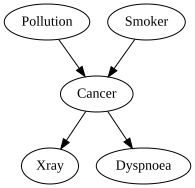

In [11]:
# Load an example model and simulate data from it.
cancer = get_example_model("cancer")
cancer_samples = cancer.simulate(n_samples=5000, seed=42)

# Plot the `cancer` model
diag = cancer.to_graphviz()
diag.layout(prog="dot")
display(diag)

  0%|          | 0/5 [00:00<?, ?it/s]

c:\Users\Nimish Purohit\pgmpy\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


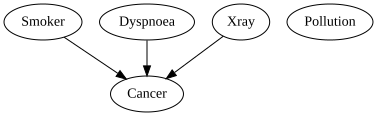

In [12]:
# Run the standard PC algorithm and plot the results

from pgmpy.estimators import PC, ExpertKnowledge

learned_model = PC(cancer_samples).estimate()

diag = learned_model.to_graphviz()
diag.layout(prog="dot")
display(diag)

As seen from the learned model, the PC algorithm was not able to correctly recover the original data-generating DAG. 

Now, we know that smoking (`Smoker`) and air pollution (`Pollution`) contribute to lung cancer (`Cancer`). Also, breathing difficulties (`Dyspnoea`) and a positive X-ray report (`Xray`) contribute to a cancer diagnosis (effect), so they cannot be the initial causes in this scenario. Based on this, we can craft a temporal order where the causes of cancer are at a higher temporal order, while the effects are lumped together at the end.

  0%|          | 0/5 [00:00<?, ?it/s]

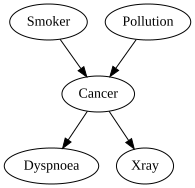

In [13]:
# PC algorithm with the temporal knowledge.

expert_knowledge = ExpertKnowledge(
    temporal_order=[["Pollution", "Smoker"], ["Cancer"], ["Dyspnoea", "Xray"]]
)

est_model = PC(cancer_samples).estimate(expert_knowledge=expert_knowledge)

diag = est_model.to_graphviz()
diag.layout(prog="dot")
display(diag)

Note: Using any form of expert knowledge, especially with PC, is sensitive to the accuracy of the knowledge.

### Expert knowledge based on search space 

  0%|          | 0/8 [00:00<?, ?it/s]

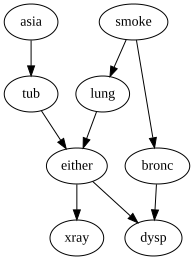

In [14]:
asia = get_example_model("asia")
asia_samples = asia.simulate(n_samples=10000, seed=42)

diag = asia.to_graphviz()
diag.layout(prog="dot")
display(diag)

Now, we can create a limited search space (white-list) such that the algorithm only considers a limited number of edges when finding the underlying causal structure. This could consist of a combination of edges that could be present with some uncertainty; and it could exclude edges that should not exist in the final model. As an example, for the `asia` model, we can consider edges from `smoking` to the three diseases present - tuberculosis (`tub`), bronchitis (`bronc`) and lung cancer (`lung`). 

In [15]:
from pgmpy.metrics import SHD

search_space = [
    ("smoke", "cancer"),
    ("smoke", "lung"),
    ("smoke", "tub"),
    ("tub", "asia"),
    ("asia", "tub"),
    ("tub", "either"),
    ("lung", "either"),
    ("either", "xray"),
    ("either", "dysp"),
    ("tub", "dysp"),
]

expert_knowledge = ExpertKnowledge(search_space=search_space)

est_model = PC(asia_samples).estimate(expert_knowledge=expert_knowledge)
SHD(asia, est_model)

  0%|          | 0/5 [00:00<?, ?it/s]

1

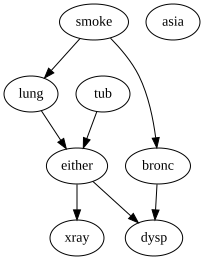

In [16]:
# Plot the estimated model

diag = est_model.to_graphviz()
diag.layout(prog="dot")
display(diag)

### Knowledge base of required and forbidden edges

  0%|          | 0/20 [00:00<?, ?it/s]

c:\Users\Nimish Purohit\pgmpy\.venv\Lib\site-packages\pygraphviz\agraph.py:1403: RuntimeWarning: Warning: pos attribute for edge (LungParench,Grunting) doesn't have 3n+1 points

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


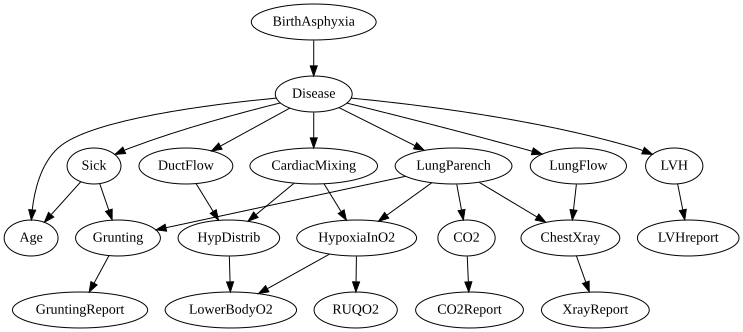

In [17]:
child = get_example_model("child")
child_samples = child.simulate(n_samples=10000, seed=42)

diag = child.to_graphviz()
diag.layout(prog="dot")
display(diag)

Based on similar reasoning as in the first section, we can now create a knowledge base consisting of forbidden and required edges. For example, having birth asphyxia ('Disease') directly contributes to the 6 subclassses/markers of disease ('LVH', 'LungParench' etc.). It is the root cause, so it cannot have incoming edges from any of these nodes. Similarly, the CO2 level ('CO2') affects the CO2 report ('CO2Report'), and not the other way around.

In [18]:
required_edges = [("CO2", "CO2Report"), ("LungFLow", "ChestXray"), ("LVH", "LVHreport")]
forbidden_edges = [
    ("Disease", "BirthAsphyxia"),
    ("Sick", "Disease"),
    ("LVH", "Disease"),
    ("DuctFlow", "Disease"),
    ("LungFlow", "Disease"),
    ("LungParench", "Disease"),
    ("CardiacMixing", "Disease"),
]

expert_knowledge = ExpertKnowledge(
    required_edges=required_edges, forbidden_edges=forbidden_edges
)
est_model = PC(child_samples).estimate(expert_knowledge=expert_knowledge)
SHD(child, est_model)

  0%|          | 0/5 [00:00<?, ?it/s]

11

c:\Users\Nimish Purohit\pgmpy\.venv\Lib\site-packages\pygraphviz\agraph.py:1403: RuntimeWarning: Warning: pos attribute for edge (Sick,Disease) doesn't have 3n+1 points

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


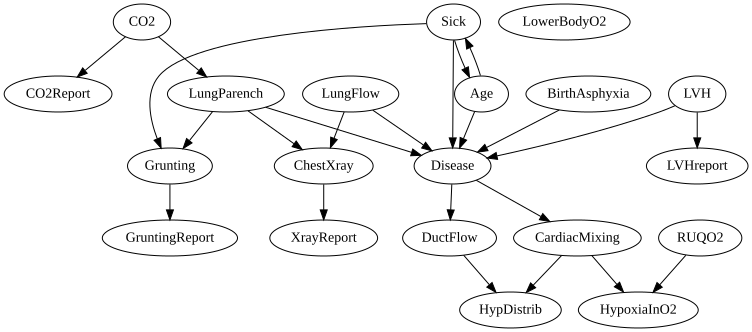

In [19]:
# Plot the estimated model

diag = est_model.to_graphviz()
diag.layout(prog="dot")
display(diag)